# Map Analysis: Model Predictions on Myanmar Territorial Control

**Models:** Focal Mask · No-Change (persistence) · Random (proportional)  
**Evaluation:** validation set only (`is_train_month == False`)

Sections:
- **Sample size** – counts table before any maps
- **A. Ground-truth maps** – actual control class across val months
- **B. Side-by-side predictions** – all models at one snapshot
- **C. Error maps** – correct vs. wrong per cell
- **D. Transition cells** – where control changed in the val set
- **E. Recall on transition cells** – per-model, spatially
- **F. Temporal evolution** – small-multiples for all val months
- **G. Summary bar charts** – overall / stable / transition metrics

In [48]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from shapely.geometry import box
import os

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
print('Project root:', ROOT)

Project root: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project


In [49]:
# ── Spatial helpers ───────────────────────────────────────────────────────────
def gid_to_latlon(gid):
    row = (gid - 1) // 720
    col = (gid - 1) % 720
    return row * 0.5 - 90.0 + 0.25, col * 0.5 - 180.0 + 0.25

def gid_to_box(gid):
    lat, lon = gid_to_latlon(gid)
    return box(lon - 0.25, lat - 0.25, lon + 0.25, lat + 0.25)

# Class colours
CLASS_COLORS = {
    'gov':       '#2166ac',
    'opo':       '#d6604d',
    'uncertain': '#fee090',
}
legend_patches = [
    mpatches.Patch(color=CLASS_COLORS['gov'],       label='Government'),
    mpatches.Patch(color=CLASS_COLORS['opo'],       label='Opposition'),
    mpatches.Patch(color=CLASS_COLORS['uncertain'], label='Uncertain/Contested'),
]

In [50]:
# ── Model paths (same 3 files as reporting.ipynb) ─────────────────────────────
PRED_PATHS = {
    'focal_mask'        : Path(ROOT) / 'models' / 'focal_mask'                / 'predictions.csv',
    'no_change'         : Path(ROOT) / 'models' / 'baseline_no_change'        / 'predictions.csv',
    'random_proportion' : Path(ROOT) / 'models' / 'baseline_random_proportion'/ 'predictions.csv',
}
MODEL_DISPLAY = {
    'focal_mask'        : 'Focal Mask',
    'no_change'         : 'No-Change\n(persistence)',
    'random_proportion' : 'Random\n(proportional)',
}
MODEL_ORDER = ['focal_mask', 'no_change', 'random_proportion']

# ── Load ──────────────────────────────────────────────────────────────────────
dfs = {}
for key in MODEL_ORDER:
    df = pd.read_csv(str(PRED_PATHS[key]))
    df['year_month'] = df['year_month'].astype(str)
    lats, lons = zip(*df['priogrid_gid'].map(gid_to_latlon))
    df['lat'] = lats;  df['lon'] = lons
    dfs[key] = df
    n_val = (~df['is_train_month']).sum()
    print(f'{MODEL_DISPLAY[key].replace(chr(10), " "):30s}  total={len(df):,}  val={n_val:,}')

# ── Validate alignment across all 3 models ────────────────────────────────────
ref_keys = frozenset(zip(dfs['focal_mask']['priogrid_gid'], dfs['focal_mask']['year_month']))
for key in MODEL_ORDER[1:]:
    ks = frozenset(zip(dfs[key]['priogrid_gid'], dfs[key]['year_month']))
    diff = (ref_keys - ks) | (ks - ref_keys)
    if diff:
        raise ValueError(
            f'Key mismatch: focal_mask vs {key} — {len(diff)} differing (gid, month) pairs.\n'
            'Re-run both scripts with the same TRAIN_CUTOFF before this notebook.'
        )
print(f'Alignment OK — all 3 models share {len(ref_keys):,} (gid, month) pairs.')

# ── Val-only views (is_train_month == False) ───────────────────────────────────
val_dfs     = {key: df[~df['is_train_month']].copy() for key, df in dfs.items()}
test_months = sorted(val_dfs['focal_mask']['year_month'].unique())
print(f'\nVal window: {test_months[0]} → {test_months[-1]}  ({len(test_months)} months)')

Focal Mask                      total=5,180  val=1,098
No-Change (persistence)         total=5,180  val=1,098
Random (proportional)           total=5,180  val=1,098
Alignment OK — all 3 models share 5,180 (gid, month) pairs.

Val window: 2025-10 → 2026-03  (6 months)


In [51]:
def build_transition_keys(any_df):
    """
    Return a frozenset of (priogrid_gid, year_month) val pairs where
    true_class at t differs from true_class at t-1.

    Uses the full series (train+val) so the first val month looks back at the
    last training month of each cell. Cells with no prior history are stable.
    Identical logic to reporting.ipynb.
    """
    df = any_df[['priogrid_gid', 'year_month', 'true_class', 'is_train_month']].copy()
    df = df.sort_values(['priogrid_gid', 'year_month']).reset_index(drop=True)
    df['prev_true'] = df.groupby('priogrid_gid')['true_class'].shift(1)
    val = df[~df['is_train_month']].copy()
    val['prev_true'] = val['prev_true'].fillna(val['true_class'])
    val['is_transition'] = val['true_class'] != val['prev_true']
    return frozenset(
        zip(
            val.loc[val['is_transition'], 'priogrid_gid'],
            val.loc[val['is_transition'], 'year_month'],
        )
    )

transition_keys = build_transition_keys(dfs['focal_mask'])
print(f'Transition events in val set: {len(transition_keys):,}')

Transition events in val set: 31


## Sample Size — Validation Set

In [52]:
ref_val = val_dfs['focal_mask']
n_cells       = ref_val['priogrid_gid'].nunique()
n_cell_months = len(ref_val)

# Per-cell transition detail
_tmp = dfs['focal_mask'][['priogrid_gid', 'year_month', 'true_class', 'is_train_month']].copy()
_tmp = _tmp.sort_values(['priogrid_gid', 'year_month']).reset_index(drop=True)
_tmp['prev_true'] = _tmp.groupby('priogrid_gid')['true_class'].shift(1)
_val = _tmp[~_tmp['is_train_month']].copy()
_val['prev_true']      = _val['prev_true'].fillna(_val['true_class'])
_val['is_transition']  = _val['true_class'] != _val['prev_true']
n_trans_events = int(_val['is_transition'].sum())
n_trans_cells  = int(_val.loc[_val['is_transition'], 'priogrid_gid'].nunique())

counts = pd.DataFrame({
    'Category': ['Overall', 'Overall', 'Overall', 'Overall', 'Transition', 'Transition'],
    'Metric': [
        'Unique cells (priogrid_gid)',
        'Cell-months (rows)',
        'Val window',
        'Val months',
        'Transition events (cell-months)',
        'Cells with ≥1 transition',
    ],
    'Value': [
        n_cells,
        n_cell_months,
        f'{test_months[0]} → {test_months[-1]}',
        len(test_months),
        n_trans_events,
        n_trans_cells,
    ],
})
display(counts.to_string(index=False))
print(f'\nTransition share: {n_trans_events}/{n_cell_months}'
      f' = {100 * n_trans_events / n_cell_months:.1f}% of val cell-months')

'  Category                          Metric             Value\n   Overall     Unique cells (priogrid_gid)               183\n   Overall              Cell-months (rows)              1098\n   Overall                      Val window 2025-10 → 2026-03\n   Overall                      Val months                 6\nTransition Transition events (cell-months)                31\nTransition        Cells with ≥1 transition                18'


Transition share: 31/1098 = 2.8% of val cell-months


In [53]:
# ── Myanmar boundaries ─────────────────────────────────────────────────────────
gadm_path = os.path.join(ROOT, 'data', 'raw', 'gadm', 'gadm41_MMR.gpkg')
mmr0 = gpd.read_file(gadm_path, layer='ADM_ADM_0')
mmr1 = gpd.read_file(gadm_path, layer='ADM_ADM_1')

# ── PRIOGRID cell geometries (full series, all gids) ──────────────────────────
unique_gids = (dfs['focal_mask'][['priogrid_gid', 'lat', 'lon']]
               .drop_duplicates('priogrid_gid'))
cells_gdf = gpd.GeoDataFrame(
    unique_gids.reset_index(drop=True),
    geometry=unique_gids['priogrid_gid'].map(gid_to_box).values,
    crs='EPSG:4326',
)
print(f'Grid: {len(cells_gdf)} cells  '
      f'lat {cells_gdf.lat.min():.1f}–{cells_gdf.lat.max():.1f}  '
      f'lon {cells_gdf.lon.min():.1f}–{cells_gdf.lon.max():.1f}')

Grid: 183 cells  lat 9.8–27.8  lon 92.2–99.8


In [54]:
# ── Map drawing helpers ────────────────────────────────────────────────────────
def draw_map(ax, month_df, col='true_class', title='', na_color='#cccccc'):
    merged = cells_gdf.merge(month_df[['priogrid_gid', col]], on='priogrid_gid', how='left')
    merged['color'] = merged[col].map(CLASS_COLORS).fillna(na_color)
    merged.plot(ax=ax, color=merged['color'].values, edgecolor='white', linewidth=0.3)
    mmr0.boundary.plot(ax=ax, color='black', linewidth=1.2)
    mmr1.boundary.plot(ax=ax, color='#555555', linewidth=0.5)
    ax.set_title(title, fontsize=10, pad=4)
    ax.axis('off'); ax.set_xlim(88, 102); ax.set_ylim(8, 29)


def draw_error_map(ax, month_df, title=''):
    merged = cells_gdf.merge(
        month_df[['priogrid_gid', 'pred_class', 'true_class']], on='priogrid_gid', how='left'
    )
    merged['color'] = (merged['pred_class'] == merged['true_class']).map(
        {True: '#4dac26', False: '#d01c8b'}
    ).fillna('#cccccc')
    merged.plot(ax=ax, color=merged['color'].values, edgecolor='white', linewidth=0.3)
    mmr0.boundary.plot(ax=ax, color='black', linewidth=1.2)
    mmr1.boundary.plot(ax=ax, color='#555555', linewidth=0.5)
    ax.set_title(title, fontsize=10, pad=4)
    ax.axis('off'); ax.set_xlim(88, 102); ax.set_ylim(8, 29)

## A. Ground-Truth Maps – Val Months

Val months (6): ['2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03']


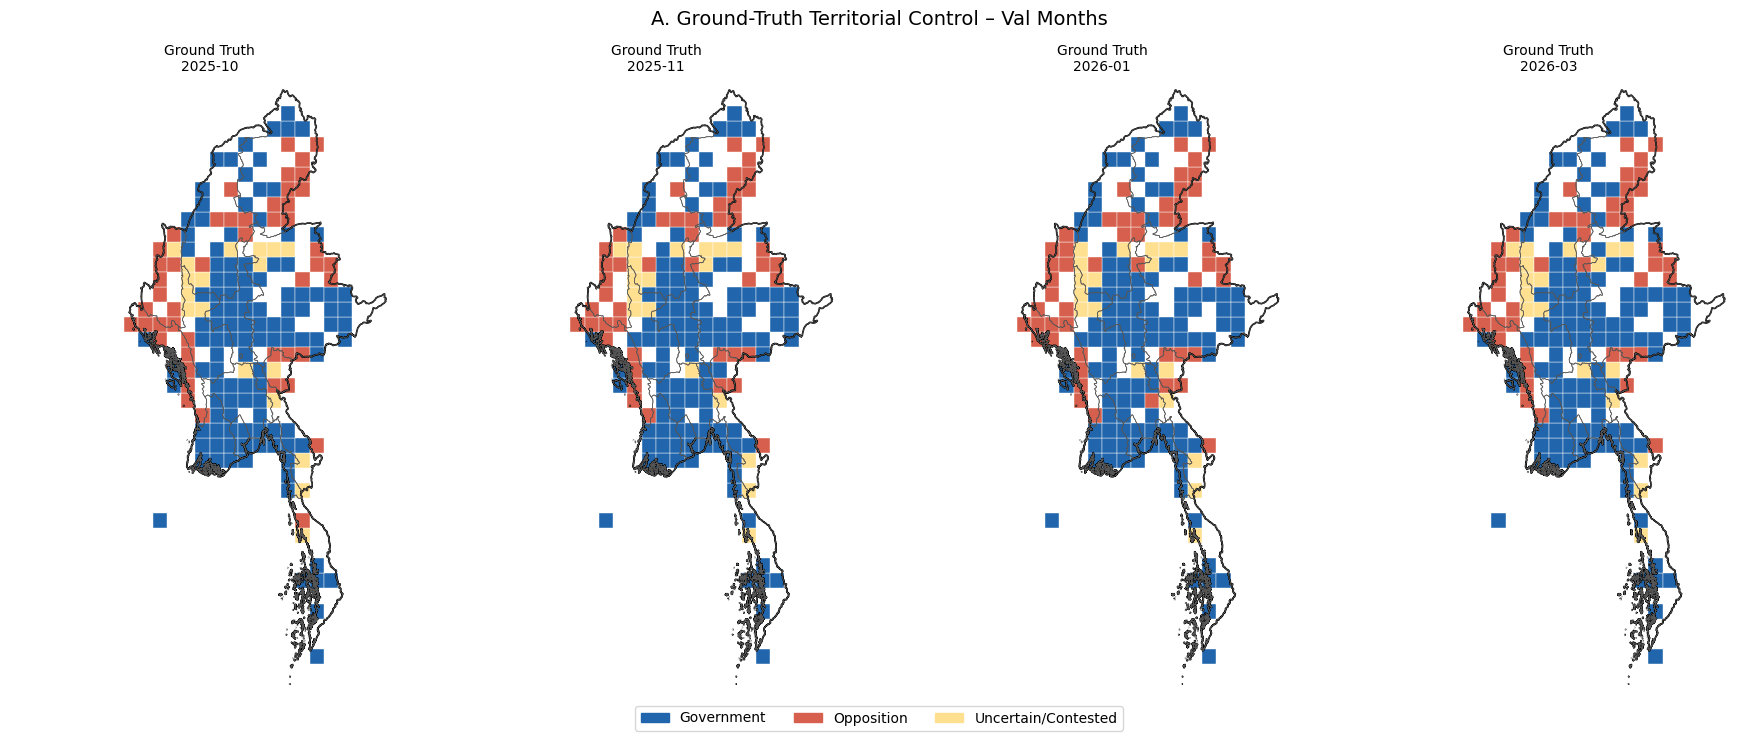

In [55]:
print(f'Val months ({len(test_months)}): {test_months}')
n_show  = min(4, len(test_months))
indices = np.linspace(0, len(test_months) - 1, n_show, dtype=int)
selected = [test_months[i] for i in indices]

fig, axes = plt.subplots(1, n_show, figsize=(4.5 * n_show, 7))
if n_show == 1:
    axes = [axes]
for ax, month in zip(axes, selected):
    draw_map(ax, val_dfs['focal_mask'][val_dfs['focal_mask'].year_month == month],
             col='true_class', title=f'Ground Truth\n{month}')

fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02), frameon=True)
fig.suptitle('A. Ground-Truth Territorial Control – Val Months', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## B. Side-by-Side Predictions – All Models at One Snapshot

Snapshot: 2026-01


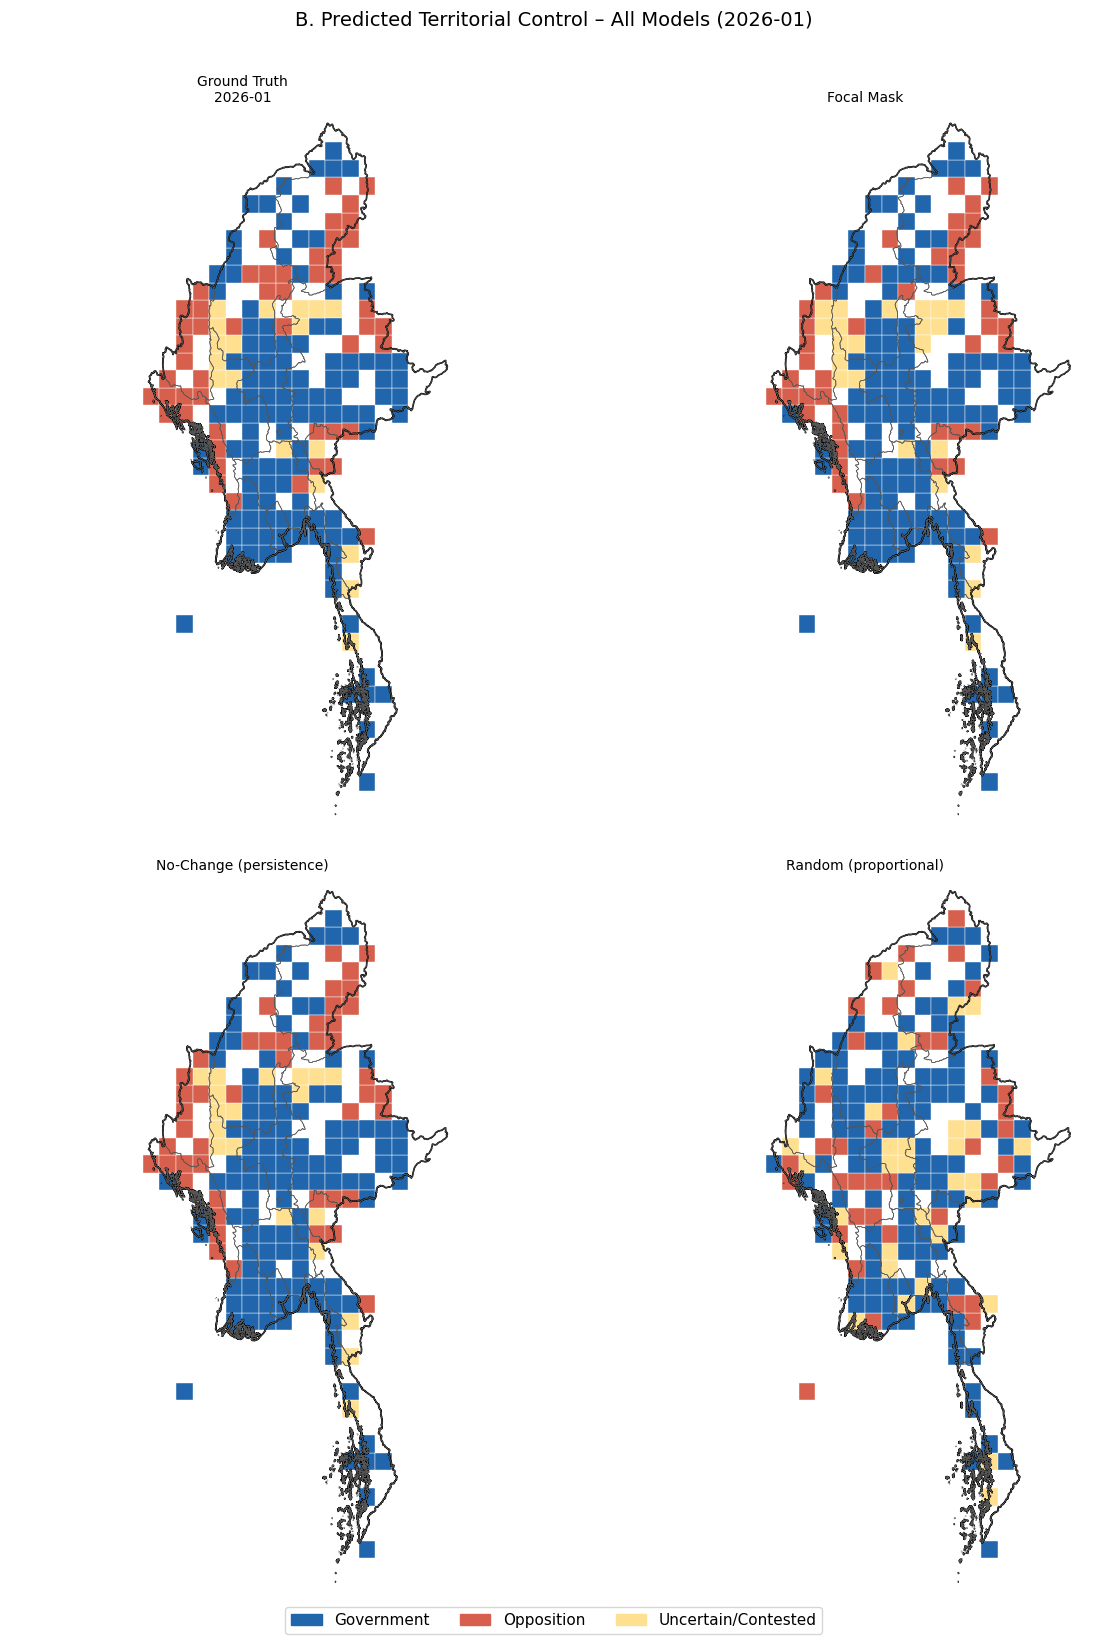

In [56]:
SNAPSHOT = test_months[len(test_months) // 2]
print(f'Snapshot: {SNAPSHOT}')

fig, axes = plt.subplots(2, 2, figsize=(14, 16))
axes = axes.flatten()

draw_map(axes[0], val_dfs['focal_mask'][val_dfs['focal_mask'].year_month == SNAPSHOT],
         col='true_class', title=f'Ground Truth\n{SNAPSHOT}')
for i, key in enumerate(MODEL_ORDER):
    mdf = val_dfs[key][val_dfs[key].year_month == SNAPSHOT]
    draw_map(axes[i + 1], mdf, col='pred_class',
             title=MODEL_DISPLAY[key].replace('\n', ' '))

fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.01), frameon=True)
fig.suptitle(f'B. Predicted Territorial Control – All Models ({SNAPSHOT})', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## C. Error Maps – Correct vs. Wrong Predictions

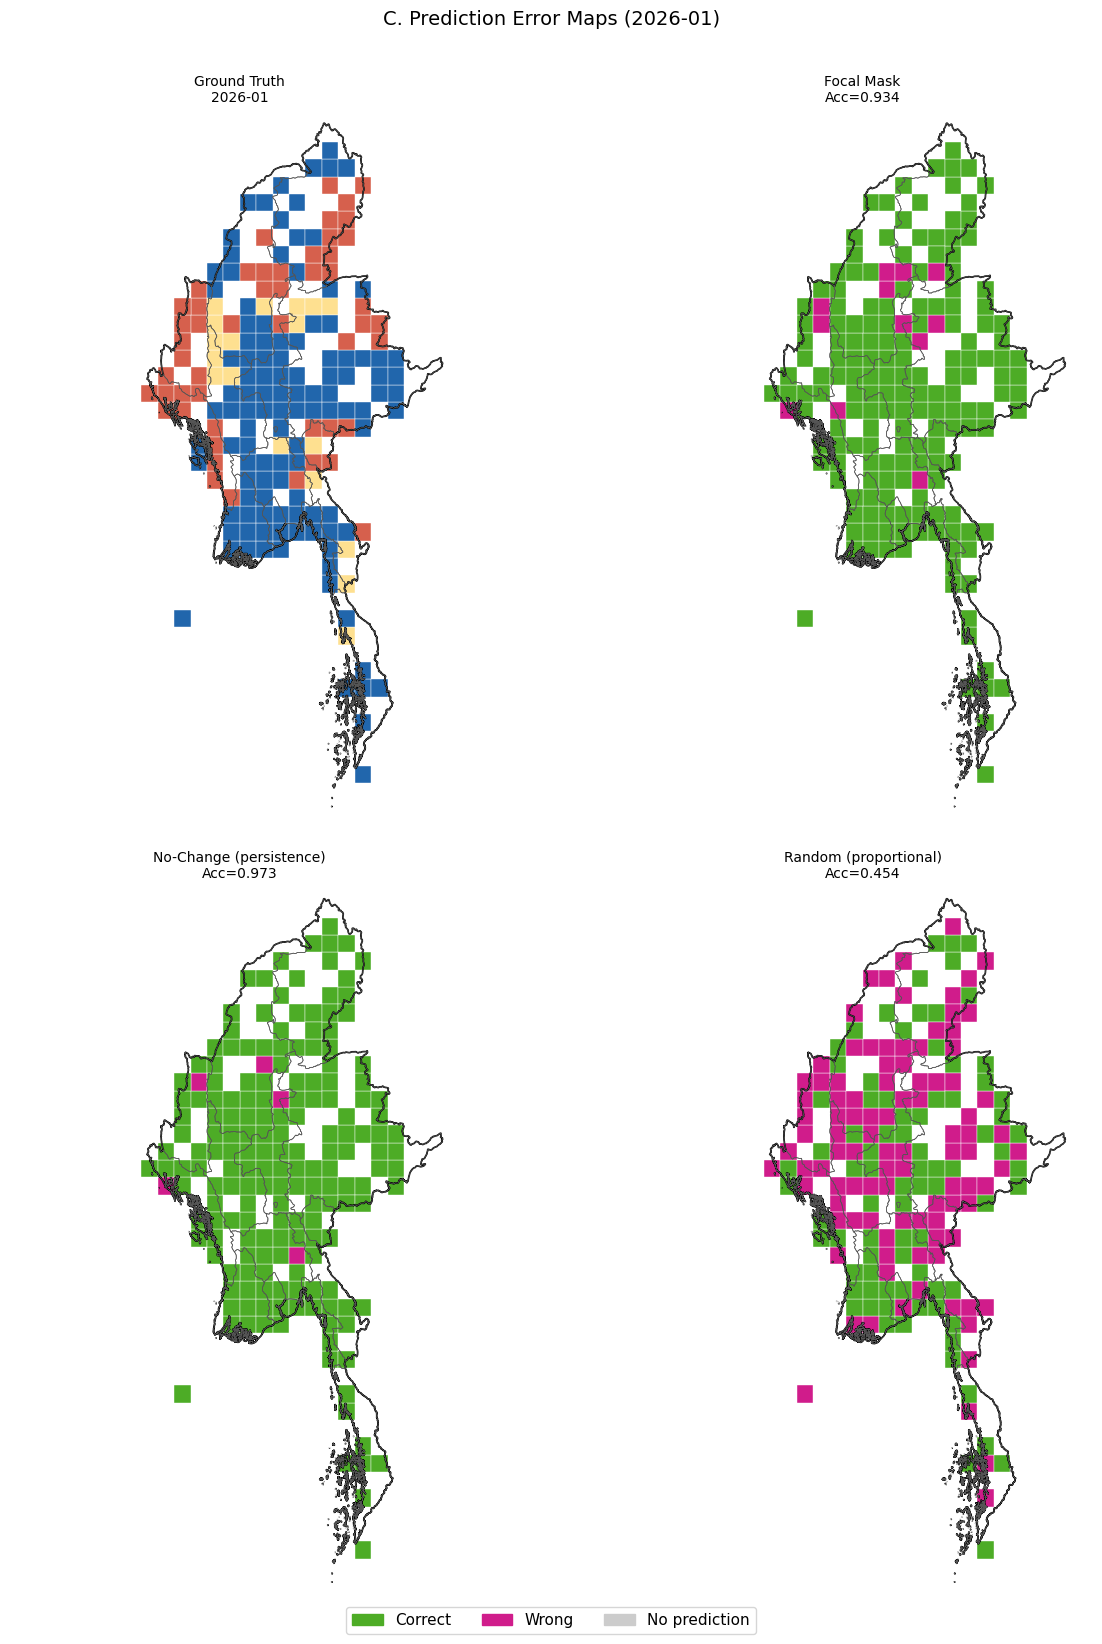

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(14, 16))
axes = axes.flatten()

draw_map(axes[0], val_dfs['focal_mask'][val_dfs['focal_mask'].year_month == SNAPSHOT],
         col='true_class', title=f'Ground Truth\n{SNAPSHOT}')
for i, key in enumerate(MODEL_ORDER):
    mdf = val_dfs[key][val_dfs[key].year_month == SNAPSHOT]
    acc = (mdf.pred_class == mdf.true_class).mean()
    draw_error_map(axes[i + 1], mdf,
                   title=f'{MODEL_DISPLAY[key].replace(chr(10), " ")}\nAcc={acc:.3f}')

err_patches = [
    mpatches.Patch(color='#4dac26', label='Correct'),
    mpatches.Patch(color='#d01c8b', label='Wrong'),
    mpatches.Patch(color='#cccccc', label='No prediction'),
]
fig.legend(handles=err_patches, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.01), frameon=True)
fig.suptitle(f'C. Prediction Error Maps ({SNAPSHOT})', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## D. Transition Cells – Where Did Control Change? (Val Set)

In [58]:
# Full-series shift so the first val month looks back at the last train month
_full = dfs['focal_mask'].copy()
_full = _full.sort_values(['priogrid_gid', 'year_month']).reset_index(drop=True)
_full['prev_true']      = _full.groupby('priogrid_gid')['true_class'].shift(1)
_full['prev_true']      = _full['prev_true'].fillna(_full['true_class'])
_full['is_transition']  = _full['true_class'] != _full['prev_true']
_full['transition_type'] = _full['prev_true'] + '→' + _full['true_class']
trans_val = _full[~_full['is_train_month']].copy()

print(f'Val transition events : {trans_val["is_transition"].sum():,}')
print(f'Unique cells          : {trans_val.loc[trans_val["is_transition"], "priogrid_gid"].nunique()}')
print('\nBreakdown:')
print(trans_val[trans_val['is_transition']]['transition_type'].value_counts().to_string())

Val transition events : 31
Unique cells          : 18

Breakdown:
transition_type
opo→gov          12
gov→opo          11
uncertain→gov     4
gov→uncertain     2
uncertain→opo     1
opo→uncertain     1


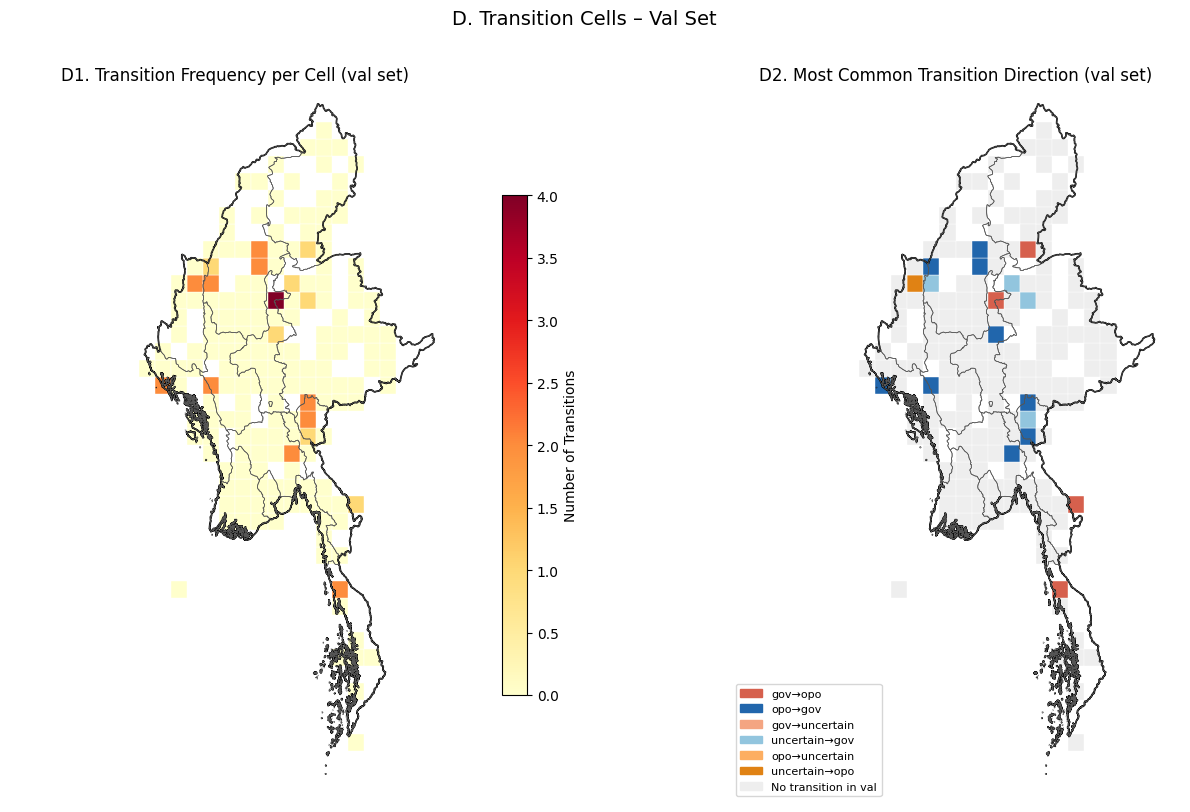

In [59]:
trans_count = (trans_val[trans_val['is_transition']]
               .groupby('priogrid_gid').size().reset_index(name='n_transitions'))
merged_tc = cells_gdf.merge(trans_count, on='priogrid_gid', how='left')
merged_tc['n_transitions'] = merged_tc['n_transitions'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

ax = axes[0]
vmax = max(merged_tc['n_transitions'].max(), 1)
merged_tc.plot(ax=ax, column='n_transitions', cmap=plt.cm.YlOrRd, vmin=0, vmax=vmax,
               edgecolor='white', linewidth=0.3, legend=True,
               legend_kwds={'label': 'Number of Transitions', 'shrink': 0.7})
mmr0.boundary.plot(ax=ax, color='black', linewidth=1.2)
mmr1.boundary.plot(ax=ax, color='#555555', linewidth=0.5)
ax.set_title('D1. Transition Frequency per Cell (val set)', fontsize=12)
ax.axis('off'); ax.set_xlim(88, 102); ax.set_ylim(8, 29)

ax = axes[1]
most_common = (trans_val[trans_val['is_transition']]
               .groupby(['priogrid_gid', 'transition_type']).size().reset_index(name='cnt')
               .sort_values('cnt', ascending=False)
               .drop_duplicates('priogrid_gid')[['priogrid_gid', 'transition_type']])
ttype_colors = {
    'gov→opo':       '#d6604d', 'opo→gov':       '#2166ac',
    'gov→uncertain': '#f4a582', 'uncertain→gov': '#92c5de',
    'opo→uncertain': '#fdae61', 'uncertain→opo': '#e08214',
}
merged_tt = cells_gdf.merge(most_common, on='priogrid_gid', how='left')
merged_tt['color'] = merged_tt['transition_type'].map(ttype_colors).fillna(
    merged_tt['transition_type'].apply(lambda x: '#cccccc' if pd.notna(x) else '#eeeeee')
)
merged_tt.plot(ax=ax, color=merged_tt['color'].values, edgecolor='white', linewidth=0.3)
mmr0.boundary.plot(ax=ax, color='black', linewidth=1.2)
mmr1.boundary.plot(ax=ax, color='#555555', linewidth=0.5)
ax.set_title('D2. Most Common Transition Direction (val set)', fontsize=12)
ax.axis('off'); ax.set_xlim(88, 102); ax.set_ylim(8, 29)

tt_patches = [mpatches.Patch(color=c, label=t) for t, c in ttype_colors.items()]
tt_patches.append(mpatches.Patch(color='#eeeeee', label='No transition in val'))
axes[1].legend(handles=tt_patches, loc='lower left', fontsize=8, frameon=True)

fig.suptitle('D. Transition Cells – Val Set', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## E. Recall on Transition Cells – Per Model, Spatially

In [60]:
recall_rows = []
for key in MODEL_ORDER:
    vdf = val_dfs[key].copy()
    vdf['_tk'] = list(zip(vdf['priogrid_gid'], vdf['year_month']))
    trans_rows = vdf[vdf['_tk'].isin(transition_keys)].copy()
    if len(trans_rows) == 0:
        continue
    trans_rows['hit'] = trans_rows['pred_class'] == trans_rows['true_class']
    cell_recall = (trans_rows.groupby('priogrid_gid')['hit'].mean()
                   .reset_index().rename(columns={'hit': 'recall'}))
    overall = trans_rows['hit'].mean()
    recall_rows.append({
        'key': key, 'label': MODEL_DISPLAY[key],
        'overall_recall': overall, 'cell_recall': cell_recall,
    })
    print(f'{MODEL_DISPLAY[key].replace(chr(10), " "):30s}  '
          f'transition recall={overall:.3f}  (n={len(trans_rows)})')

Focal Mask                      transition recall=0.419  (n=31)
No-Change (persistence)         transition recall=0.000  (n=31)
Random (proportional)           transition recall=0.323  (n=31)


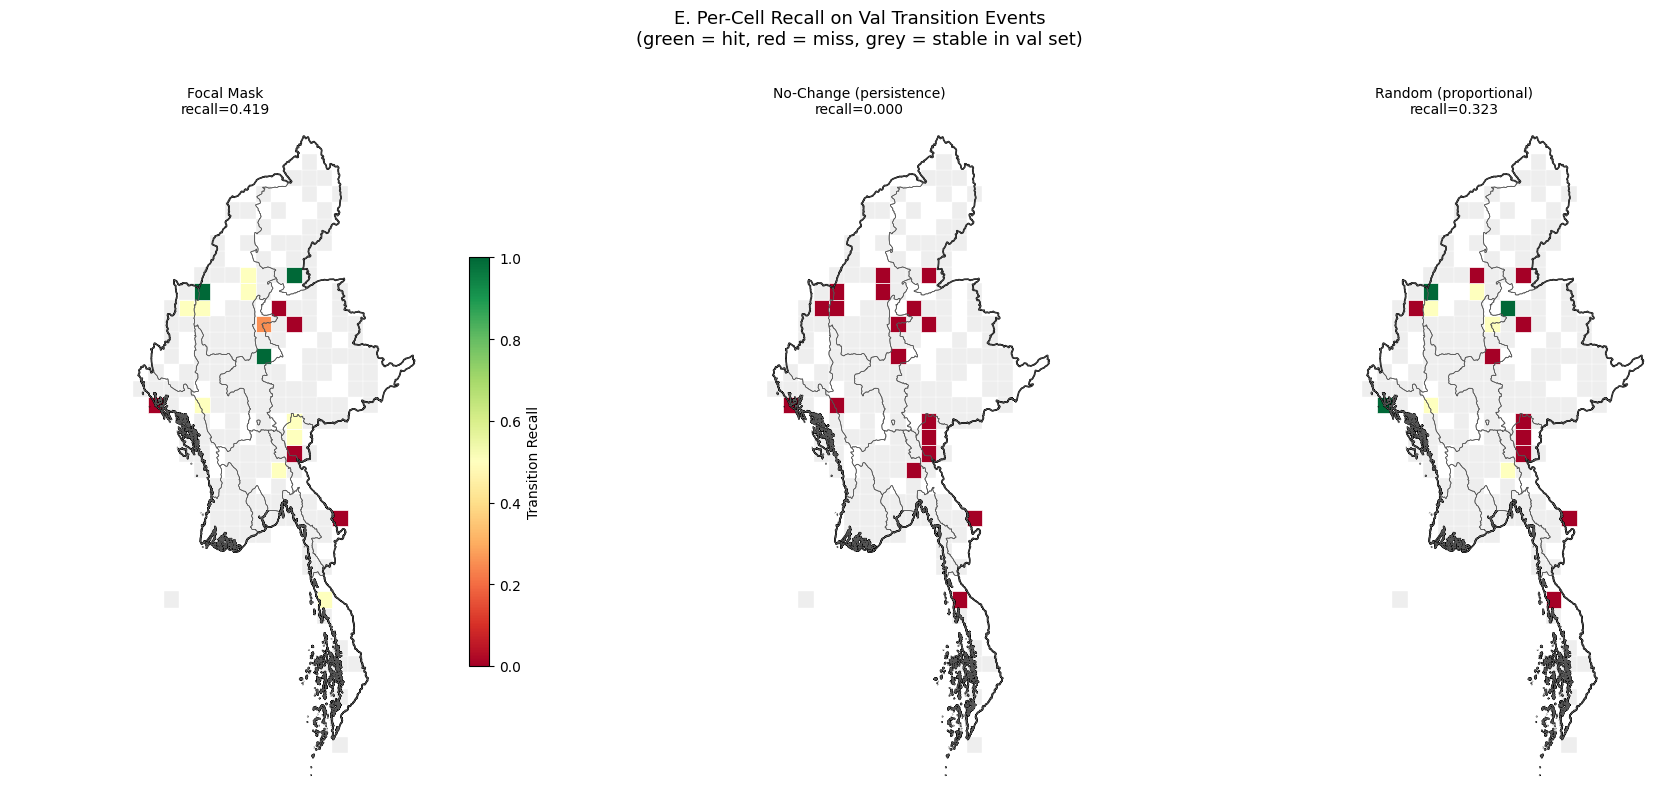

In [61]:
n_rec = len(recall_rows)
fig, axes = plt.subplots(1, n_rec, figsize=(6 * n_rec, 8))
if n_rec == 1:
    axes = [axes]
axes = np.array(axes).flatten()

for i, row in enumerate(recall_rows):
    ax = axes[i]
    merged_r = cells_gdf.merge(row['cell_recall'], on='priogrid_gid', how='left')
    no_trans = merged_r['recall'].isna()
    merged_r[no_trans].plot(ax=ax, color='#eeeeee', edgecolor='white', linewidth=0.3)
    if not merged_r[~no_trans].empty:
        merged_r[~no_trans].plot(ax=ax, column='recall', cmap='RdYlGn', vmin=0, vmax=1,
                                 edgecolor='white', linewidth=0.5,
                                 legend=(i == 0),
                                 legend_kwds={'label': 'Transition Recall', 'shrink': 0.6})
    mmr0.boundary.plot(ax=ax, color='black', linewidth=1.2)
    mmr1.boundary.plot(ax=ax, color='#555555', linewidth=0.5)
    ax.set_title(f'{row["label"].replace(chr(10), " ")}\n'
                 f'recall={row["overall_recall"]:.3f}', fontsize=10)
    ax.axis('off'); ax.set_xlim(88, 102); ax.set_ylim(8, 29)

fig.suptitle('E. Per-Cell Recall on Val Transition Events\n'
             '(green = hit, red = miss, grey = stable in val set)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## F. Temporal Evolution – All Models × All Val Months

Months: ['2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03']


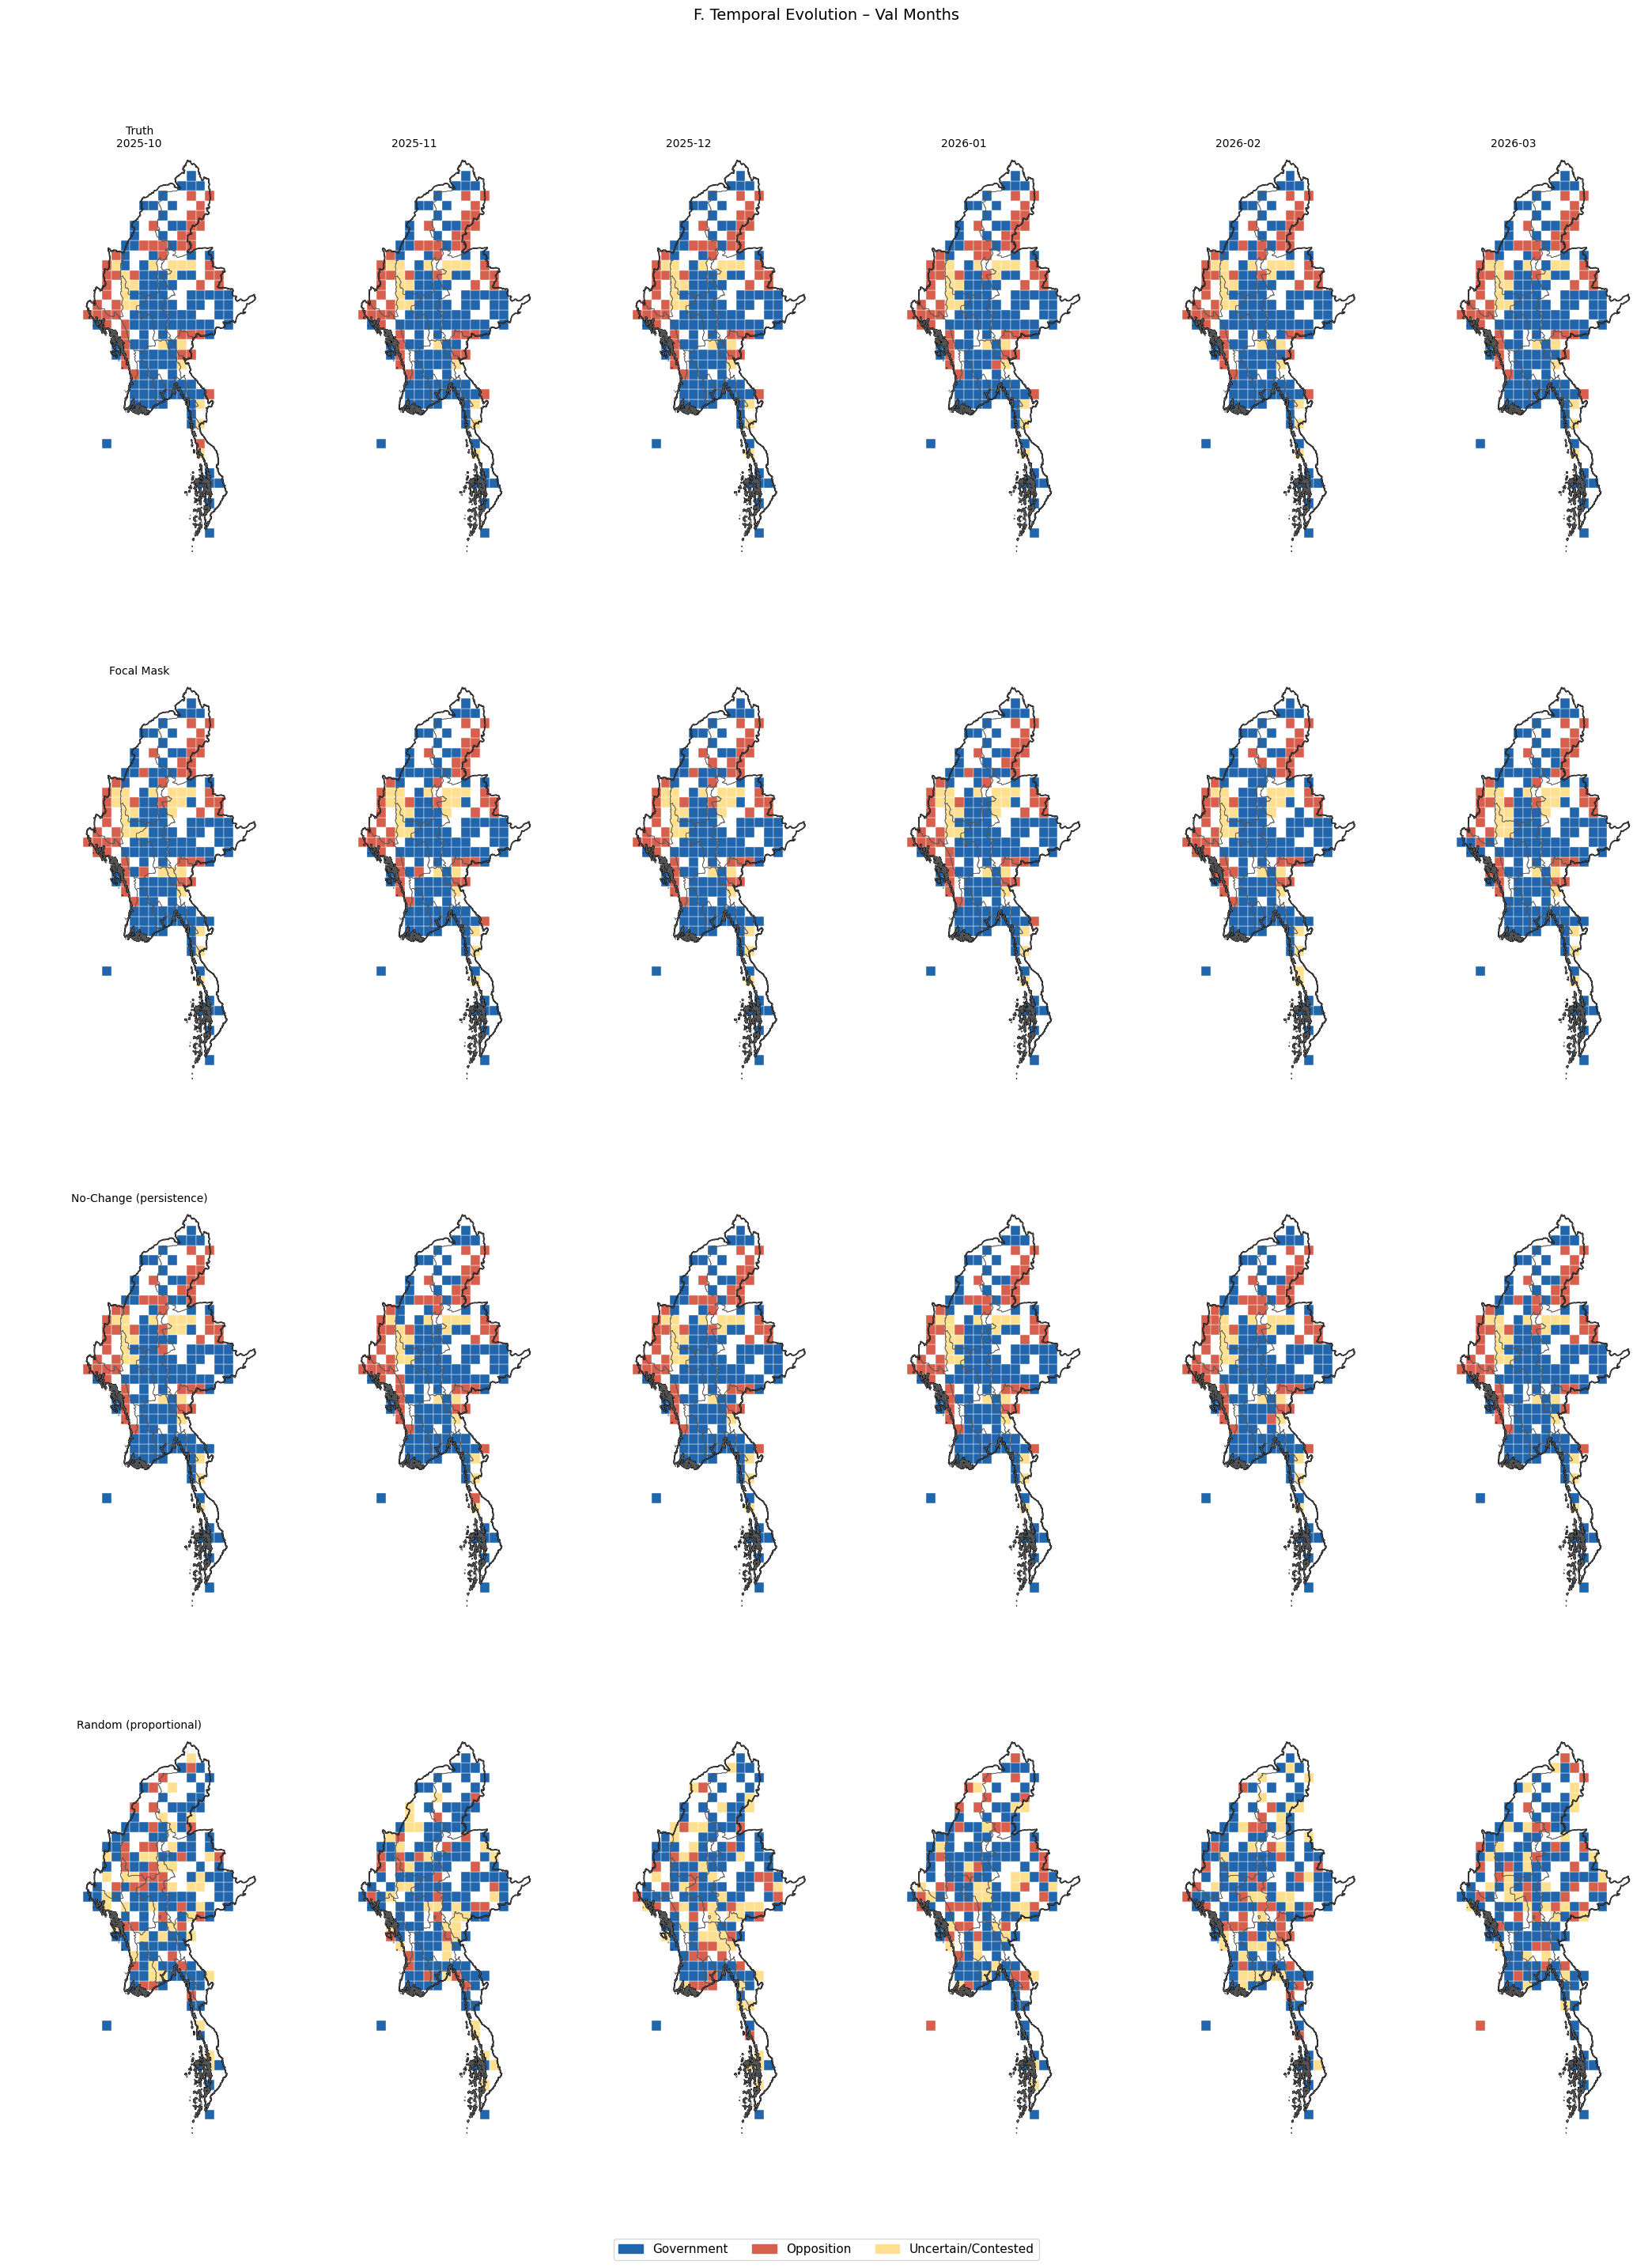

In [62]:
MAX_COLS = 6
plot_months = test_months if len(test_months) <= MAX_COLS else [
    test_months[i] for i in np.linspace(0, len(test_months) - 1, MAX_COLS, dtype=int)
]
print('Months:', plot_months)

nrows = len(MODEL_ORDER) + 1
ncols = len(plot_months)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 7 * nrows))
if ncols == 1:
    axes = axes[:, np.newaxis]

for c, month in enumerate(plot_months):
    draw_map(axes[0, c],
             val_dfs['focal_mask'][val_dfs['focal_mask'].year_month == month],
             col='true_class', title=f'Truth\n{month}' if c == 0 else month)
    for r, key in enumerate(MODEL_ORDER):
        mdf = val_dfs[key][val_dfs[key].year_month == month]
        draw_map(axes[r + 1, c], mdf, col='pred_class',
                 title=MODEL_DISPLAY[key].replace('\n', ' ') if c == 0 else '')

row_labels = ['Ground Truth'] + [MODEL_DISPLAY[k].replace('\n', ' ') for k in MODEL_ORDER]
for r, lbl in enumerate(row_labels):
    axes[r, 0].set_ylabel(lbl, fontsize=9, labelpad=4)

fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.01), frameon=True)
fig.suptitle('F. Temporal Evolution – Val Months', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## G. Summary: Stable vs. Transition Performance (Val Set)

In [63]:
rows = []
for key in MODEL_ORDER:
    vdf = val_dfs[key].copy()
    vdf['_tk'] = list(zip(vdf['priogrid_gid'], vdf['year_month']))
    v_trans  = vdf[vdf['_tk'].isin(transition_keys)]
    v_stable = vdf[~vdf['_tk'].isin(transition_keys)]
    rows.append({
        'Model': MODEL_DISPLAY[key].replace('\n', ' '),
        'Overall Acc'       : (vdf.pred_class == vdf.true_class).mean(),
        'Stable Acc'        : (v_stable.pred_class == v_stable.true_class).mean() if len(v_stable) else np.nan,
        'Transition Recall' : (v_trans.pred_class == v_trans.true_class).mean() if len(v_trans) else np.nan,
        'N Transition Events': len(v_trans),
    })

summary = pd.DataFrame(rows).set_index('Model')
display(summary.round(4))

,Overall Acc,Stable Acc,Transition Recall,N Transition Events
Model,,,,
Focal Mask,0.9317,0.9466,0.4194,31
No-Change (persistence),0.9718,1.0000,0.0000,31
Random (proportional),0.4636,0.4677,0.3226,31


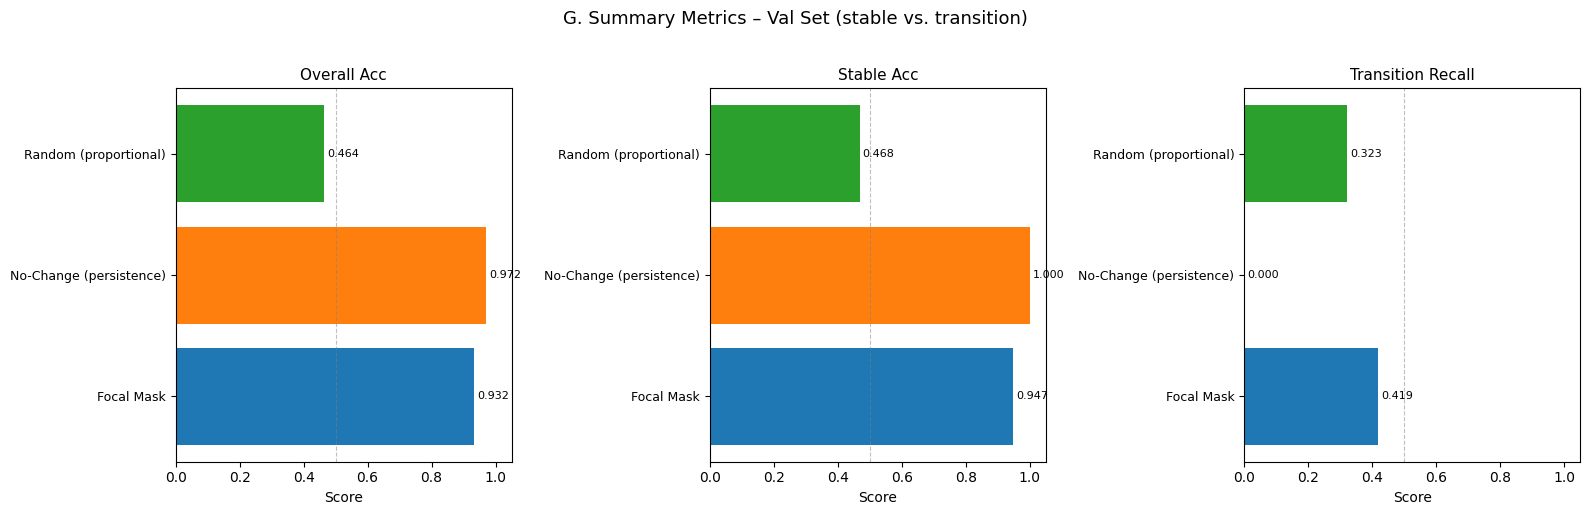

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = plt.cm.tab10.colors

for ax, metric in zip(axes, ['Overall Acc', 'Stable Acc', 'Transition Recall']):
    vals = summary[metric].dropna()
    bars = ax.barh(range(len(vals)), vals.values, color=colors[:len(vals)])
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels([l[:32] for l in vals.index], fontsize=9)
    ax.set_xlabel('Score', fontsize=10)
    ax.set_title(metric, fontsize=11)
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=8)
    ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)

fig.suptitle('G. Summary Metrics – Val Set (stable vs. transition)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()